# Notebook 3 — Fine-Tune InceptionResNetV2

This notebook fine-tunes the selected InceptionResNetV2 model after the frozen-model comparison in Notebook 2.

A **GPU runtime** such as a T4 is suitable.

Notebook 2 inputs are read from:

```text
/content/drive/MyDrive/restricted-dog-cnn/model_zoo
```

Fine-tuning outputs are written to:

```text
/content/drive/MyDrive/restricted-dog-cnn/fine_tuning
```


## 0. Mount Google Drive and define project paths

This cell uses the same fixed folder structure as Notebooks 1 and 2.

In [ ]:
# ============================================================
# 0. Mount Google Drive and define project paths
# ============================================================
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_FOLDER_NAME = "restricted-dog-cnn"
PROJECT_ROOT = Path("/content/drive/MyDrive") / PROJECT_FOLDER_NAME

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

# Inputs created by Notebook 2
MODEL_ROOT = PROJECT_ROOT / "model_zoo"
MODEL_CHECKPOINT_DIR = MODEL_ROOT / "checkpoints"
MODEL_LOG_DIR = MODEL_ROOT / "logs"
MODEL_FIGURE_DIR = MODEL_ROOT / "figures"
MODEL_PREDICTION_DIR = MODEL_ROOT / "predictions"

# Outputs created by Notebook 3
FINE_TUNE_ROOT = PROJECT_ROOT / "fine_tuning"
FT_CHECKPOINT_DIR = FINE_TUNE_ROOT / "checkpoints"
FT_LOG_DIR = FINE_TUNE_ROOT / "logs"
FT_FIGURE_DIR = FINE_TUNE_ROOT / "figures"
FT_PREDICTION_DIR = FINE_TUNE_ROOT / "predictions"

for folder in [
    FINE_TUNE_ROOT,
    FT_CHECKPOINT_DIR,
    FT_LOG_DIR,
    FT_FIGURE_DIR,
    FT_PREDICTION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder: ", DATA_DIR)
print("Model zoo:   ", MODEL_ROOT)
print("Fine tuning: ", FINE_TUNE_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/restricted-dog-computer-vision
Data folder:  /content/drive/MyDrive/restricted-dog-computer-vision/data
Model zoo:    /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo
Fine tuning:  /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning


## 1. Imports and core configuration

The batch size is deliberately kept at 8 because InceptionResNetV2 is memory-heavy on Colab T4.

In [ ]:
# ============================================================
# 1. Imports and core configuration
# ============================================================

import gc
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
)

SEED = 58
BATCH_SIZE = 8
EPOCHS = 15
PATIENCE = 4
LEARNING_RATE = 1e-5
THRESHOLD = 0.5
UNFREEZE_LAST_N = 20

CLASS_NAMES = ["unrestricted", "restricted"]
IMAGE_SIZE = (299, 299)

SELECTED_MODEL = "InceptionResNetV2"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Configuration")
print("Seed:", SEED)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)
print("Threshold:", THRESHOLD)
print("Unfreeze last N layers:", UNFREEZE_LAST_N)
print("Selected model:", SELECTED_MODEL)

Configuration
Seed: 58
Batch size: 8
Epochs: 15
Patience: 4
Learning rate: 1e-05
Threshold: 0.5
Unfreeze last N layers: 20
Selected model: InceptionResNetV2


## 2. Verify GPU

Fine-tuning should be run on a GPU. If this cell fails, change the Colab runtime type to T4 GPU before continuing.

In [ ]:
# ============================================================
# 2. Verify GPU
# ============================================================

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if not gpus:
    raise RuntimeError(
        "No GPU detected. For Notebook 3, use: Runtime -> Change runtime type -> T4 GPU."
    )

print("GPU detected:")
for gpu in gpus:
    print(" -", gpu)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth for", gpu, "because:", e)

TensorFlow version: 2.20.0
GPU detected:
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 3. Verify dataset and Notebook 2 outputs

This cell checks that Notebook 1 created the dataset and Notebook 2 saved the selected frozen model.

In [ ]:
# ============================================================
# 3. Verify dataset and Notebook 2 outputs
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}


def count_images(folder: Path) -> int:
    if not folder.exists():
        return 0
    return sum(1 for p in folder.rglob("*") if p.suffix in IMAGE_EXTENSIONS)


required_folders = []
for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for class_name in CLASS_NAMES:
        required_folders.append(split_dir / class_name)

missing_or_empty = []

print("=" * 70)
print("DATASET VERIFICATION")
print("=" * 70)

for folder in required_folders:
    n = count_images(folder)
    status = "OK" if folder.exists() and n > 0 else "MISSING/EMPTY"
    print(f"{status:14s} {folder}: {n} images")
    if not folder.exists() or n == 0:
        missing_or_empty.append(folder)

if missing_or_empty:
    missing_text = "\n".join(str(p) for p in missing_or_empty)
    raise FileNotFoundError(
        "Notebook 1 has not produced a complete dataset split.\n"
        "Missing or empty folders:\n"
        f"{missing_text}"
    )

frozen_model_path = MODEL_CHECKPOINT_DIR / f"{SELECTED_MODEL}_best.keras"

if not frozen_model_path.exists():
    raise FileNotFoundError(
        "Could not find frozen model checkpoint:\n"
        f"{frozen_model_path}\n\n"
        "Run Notebook 2 first."
    )

print("=" * 70)
print("Dataset split is complete.")
print("Found frozen model checkpoint:", frozen_model_path)

DATASET VERIFICATION
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/train/unrestricted: 2462 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/train/restricted: 561 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/val/unrestricted: 816 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/val/restricted: 186 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/test/unrestricted: 838 images
OK             /content/drive/MyDrive/restricted-dog-computer-vision/data/test/restricted: 190 images
Dataset split is complete.
Found frozen model checkpoint: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/InceptionResNetV2_best.keras


## 4. Load Notebook 2 benchmark results

This records the context for choosing the fine-tuning model.

In [ ]:
# ============================================================
# 4. Load Notebook 2 benchmark results
# ============================================================

results_csv = MODEL_LOG_DIR / "model_zoo_results.csv"
partial_csv = MODEL_LOG_DIR / "model_zoo_results_partial.csv"

if results_csv.exists():
    model_zoo_results = pd.read_csv(results_csv)
elif partial_csv.exists():
    model_zoo_results = pd.read_csv(partial_csv)
else:
    raise FileNotFoundError(
        "Could not find model_zoo_results.csv or model_zoo_results_partial.csv in model_zoo/logs."
    )

print("Notebook 2 model zoo results:")
display(model_zoo_results.round(4))

if "model" in model_zoo_results.columns:
    selected_row = model_zoo_results[model_zoo_results["model"] == SELECTED_MODEL]
    if not selected_row.empty:
        print("Selected frozen baseline:")
        display(selected_row.round(4))

Notebook 2 model zoo results:


,model,accuracy,precision,recall,f1,auc,pr_auc,mcc,tn,fp,fn,tp,epochs_trained,threshold,input_height,input_width
0,VGG16,0.8735,0.6034,0.9211,0.7292,0.9467,0.8259,0.6761,723,115,15,175,20,0.5,224,224
1,ResNet50,0.9173,0.7092,0.9368,0.8073,0.9738,0.8986,0.7678,765,73,12,178,20,0.5,224,224
2,InceptionV3,0.9611,0.8440,0.9684,0.9020,0.9935,0.9687,0.8811,804,34,6,184,20,0.5,299,299
3,Xception,0.9601,0.8371,0.9737,0.9002,0.9939,0.9744,0.8794,802,36,5,185,20,0.5,299,299
4,InceptionResNetV2,0.9679,0.8685,0.9737,0.9181,0.9968,0.9872,0.9005,810,28,5,185,20,0.5,299,299
5,NASNetMobile,0.9484,0.7991,0.9632,0.8735,0.9880,0.9526,0.8473,792,46,7,183,20,0.5,224,224


Selected frozen baseline:


,model,accuracy,precision,recall,f1,auc,pr_auc,mcc,tn,fp,fn,tp,epochs_trained,threshold,input_height,input_width
4,InceptionResNetV2,0.9679,0.8685,0.9737,0.9181,0.9968,0.9872,0.9005,810,28,5,185,20,0.5,299,299


## 5. Compute class weights

The restricted class is smaller, so class weighting is retained during fine-tuning.

In [ ]:
# ============================================================
# 5. Compute class weights
# ============================================================

n_unrestricted = count_images(TRAIN_DIR / "unrestricted")
n_restricted = count_images(TRAIN_DIR / "restricted")
n_total = n_unrestricted + n_restricted

if n_unrestricted == 0 or n_restricted == 0:
    raise RuntimeError(
        f"Training folders must contain both classes. "
        f"Found unrestricted={n_unrestricted}, restricted={n_restricted}"
    )

CLASS_WEIGHT = {
    0: n_total / (2 * n_unrestricted),
    1: n_total / (2 * n_restricted),
}

print("Training counts")
print("Unrestricted:", n_unrestricted)
print("Restricted:  ", n_restricted)
print("Total:       ", n_total)
print("Class weight:", CLASS_WEIGHT)

Training counts
Unrestricted: 2462
Restricted:   561
Total:        3023
Class weight: {0: 0.613931762794476, 1: 2.694295900178253}


## 6. Dataset loader

The selected model uses 299 × 299 input images.

In [ ]:
# ============================================================
# 6. Dataset loader
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def make_raw_dataset(directory: Path, image_size: tuple[int, int], shuffle: bool):
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="binary",
        class_names=CLASS_NAMES,
        image_size=image_size,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED if shuffle else None,
    )


def make_datasets(image_size: tuple[int, int]):
    train_ds = make_raw_dataset(TRAIN_DIR, image_size=image_size, shuffle=True)
    val_ds = make_raw_dataset(VAL_DIR, image_size=image_size, shuffle=False)
    test_ds = make_raw_dataset(TEST_DIR, image_size=image_size, shuffle=False)

    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds


train_ds, val_ds, test_ds = make_datasets(IMAGE_SIZE)

print("Datasets ready.")
print("Image size:", IMAGE_SIZE)
print("Class names:", CLASS_NAMES)

Found 3023 files belonging to 2 classes.
Found 1002 files belonging to 2 classes.
Found 1028 files belonging to 2 classes.
Datasets ready.
Image size: (299, 299)
Class names: ['unrestricted', 'restricted']


## 7. Load the best frozen model from Notebook 2

The starting point is the best checkpoint from the frozen transfer-learning benchmark.

In [ ]:
# ============================================================
# 7. Load the best frozen model from Notebook 2
# ============================================================

model = tf.keras.models.load_model(frozen_model_path)

print("Loaded model:", frozen_model_path)
print("Model name:", model.name)
print("Parameters:", f"{model.count_params():,}")

model.summary()

Loaded model: /content/drive/MyDrive/restricted-dog-computer-vision/model_zoo/checkpoints/InceptionResNetV2_best.keras
Model name: InceptionResNetV2_frozen
Parameters: 54,338,273


Model: "InceptionResNetV2_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_flip (RandomFlip)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_rotation (RandomRotation)   │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_zoom (RandomZoom)           │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_resnet_v2             │ (None, 8, 8, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ restricted_probability (Dense)  │ (None, 1)              │         1,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,341,349 (207.30 MB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 54,336,736 (207.28 MB)

 Optimizer params: 3,076 (12.02 KB)

## 8. Locate the pretrained base model and unfreeze its top layers

Only the last few layers are unfrozen. This gives the model some task-specific flexibility without overfitting too aggressively.

In [ ]:
# ============================================================
# 8. Locate base model and unfreeze top layers
# ============================================================

base_model = None

for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

if base_model is None:
    raise RuntimeError("Could not locate nested pretrained base model inside the loaded model.")

print("Base model:", base_model.name)
print("Base model layers:", len(base_model.layers))

base_model.trainable = True

for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
frozen_count = sum(1 for layer in base_model.layers if not layer.trainable)

print("Frozen base layers:   ", frozen_count)
print("Trainable base layers:", trainable_count)

Base model: inception_resnet_v2
Base model layers: 780
Frozen base layers:    760
Trainable base layers: 20


## 9. Compile the fine-tuning model

Fine-tuning uses a much smaller learning rate than the frozen-head training stage.

In [ ]:
# ============================================================
# 9. Compile fine-tuning model
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy", threshold=THRESHOLD),
        tf.keras.metrics.Precision(name="precision", thresholds=THRESHOLD),
        tf.keras.metrics.Recall(name="recall", thresholds=THRESHOLD),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
    ],
)

print("Fine-tuning model compiled.")

Fine-tuning model compiled.


## 10. Helper functions for evaluation and plots

In [ ]:
# ============================================================
# 10. Helper functions for evaluation and plots
# ============================================================


def collect_predictions(model: tf.keras.Model, dataset):
    y_true = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0).reshape(-1)
        y_prob.extend(probs.tolist())
        y_true.extend(labels.numpy().reshape(-1).astype(int).tolist())

    return np.array(y_true, dtype=int), np.array(y_prob, dtype=float)


def compute_metrics(y_true, y_prob, threshold: float = THRESHOLD) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    output = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    if len(np.unique(y_true)) == 2:
        output["auc"] = roc_auc_score(y_true, y_prob)
        output["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        output["auc"] = np.nan
        output["pr_auc"] = np.nan

    return output


def save_learning_curve(history: dict):
    epochs = range(1, len(history["loss"]) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history["accuracy"], label="Train accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
    plt.plot(epochs, history["loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Validation loss")
    plt.title("Fine-tuned InceptionResNetV2 Learning Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Metric / Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    out_path = FT_FIGURE_DIR / "FineTuned_InceptionResNetV2_learning_curves.png"
    plt.savefig(out_path, dpi=300, facecolor="white")
    plt.show()
    plt.close()

    return out_path


def save_confusion_matrix_plot(
    y_true,
    y_prob,
    model_name="Model",
    threshold=0.5,
):
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(7, 7))

    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

    ax.set_title(f"{model_name} Confusion Matrix", fontsize=20, pad=20)

    classes = ["Unrestricted", "Restricted"]

    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    ax.set_xticklabels(classes, fontsize=16)
    ax.set_yticklabels(classes, fontsize=16)

    ax.set_xlabel("Predicted", fontsize=18)
    ax.set_ylabel("True", fontsize=18)

    threshold_value = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            color = "white" if cm[i, j] > threshold_value else "black"

            ax.text(
                j,
                i,
                f"{cm[i, j]}",
                ha="center",
                va="center",
                fontsize=22,
                fontweight="bold",
                color=color,
            )

    plt.colorbar(im)

    plt.tight_layout()

    out_path = FT_FIGURE_DIR / f"{model_name}_confusion_matrix.png"

    plt.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.close()

    return out_path


print("Evaluation helpers ready.")

Evaluation helpers ready.


## 11. Fine-tune safely

This cell skips training if the complete fine-tuned output set already exists.

Epoch 1/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9444 - auc: 0.9861 - loss: 0.2360 - pr_auc: 0.9357 - precision: 0.8853 - recall: 0.8115
Epoch 1: val_loss improved from None to 0.06578, saving model to /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/checkpoints/FineTuned_InceptionResNetV2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/checkpoints/FineTuned_InceptionResNetV2_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 1712s 4s/step - accuracy: 0.9517 - auc: 0.9832 - loss: 0.1825 - pr_auc: 0.9214 - precision: 0.8511 - recall: 0.8966 - val_accuracy: 0.9671 - val_auc: 0.9964 - val_loss: 0.0658 - val_pr_auc: 0.9852 - val_precision: 0.8844 - val_recall: 0.9462
Epoch 2/15
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9648 - auc: 0.9948 - loss: 0.0923 - pr_auc: 0.9760 - precision: 0.8551 - recall: 0.9730
Epoch 2: val_loss improved from 0.06578 to 0.05705, saving model to /content/drive/MyD

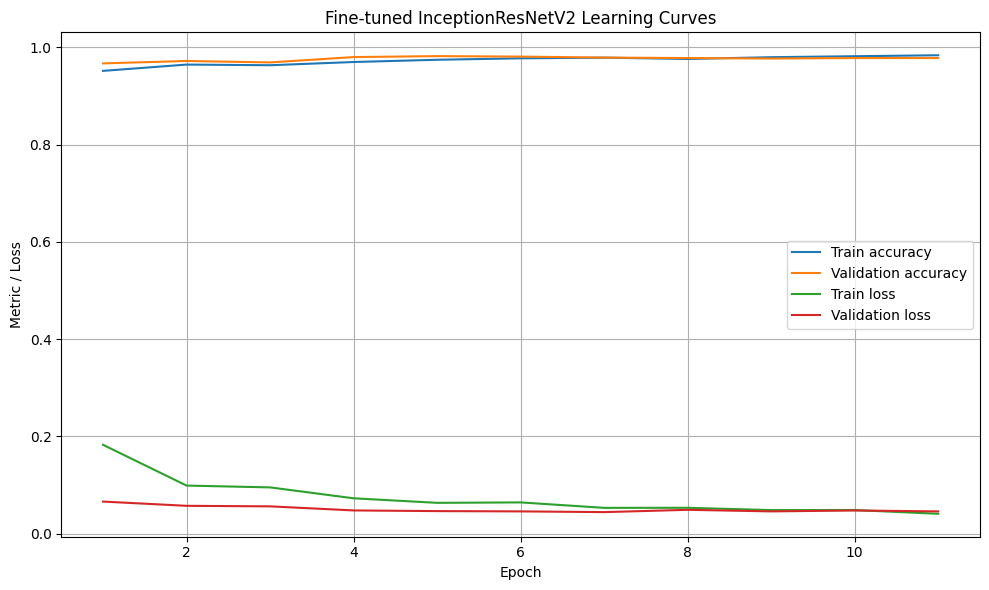

Fine-tuning stage finished or skipped.


In [ ]:
# ============================================================
# 11. Fine-tune safely, skipping if already complete
# ============================================================

checkpoint_path = FT_CHECKPOINT_DIR / "FineTuned_InceptionResNetV2_best.keras"
history_path = FT_LOG_DIR / "fine_tuning_history.json"
training_log_path = FT_LOG_DIR / "fine_tuning_training_log.csv"
metrics_path = FT_LOG_DIR / "fine_tuning_metrics.csv"
prediction_path = FT_PREDICTION_DIR / "fine_tuning_test_predictions.csv"
curve_path = FT_FIGURE_DIR / "FineTuned_InceptionResNetV2_learning_curves.png"
confusion_path = FT_FIGURE_DIR / "FineTuned_InceptionResNetV2_confusion_matrix.png"

already_done = (
    checkpoint_path.exists()
    and history_path.exists()
    and metrics_path.exists()
    and prediction_path.exists()
    and curve_path.exists()
    and confusion_path.exists()
)

if already_done:
    print("Fine-tuned model already complete. Skipping training.")
else:
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(training_log_path), append=False),
    ]

    history_obj = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=CLASS_WEIGHT,
        verbose=1,
    )

    history = history_obj.history

    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    save_learning_curve(history)

    del history_obj
    gc.collect()

print("Fine-tuning stage finished or skipped.")

## 12. Evaluate the fine-tuned model on the test set

This cell reloads the best checkpoint before evaluation.

In [ ]:
# ============================================================
# 12. Evaluate fine-tuned model on test set
# ============================================================

if not checkpoint_path.exists():
    raise FileNotFoundError(
        "Fine-tuned checkpoint not found:\n"
        f"{checkpoint_path}\n\n"
        "Run the fine-tuning cell first."
    )

best_model = tf.keras.models.load_model(checkpoint_path)

y_true, y_prob = collect_predictions(best_model, test_ds)
metrics = compute_metrics(y_true, y_prob, threshold=THRESHOLD)

metrics["model"] = "FineTuned_InceptionResNetV2"
metrics["base_model"] = SELECTED_MODEL
metrics["epochs_allowed"] = EPOCHS
metrics["unfreeze_last_n"] = UNFREEZE_LAST_N
metrics["learning_rate"] = LEARNING_RATE
metrics["input_height"] = IMAGE_SIZE[0]
metrics["input_width"] = IMAGE_SIZE[1]

metrics_df = pd.DataFrame([metrics])
metrics_df.to_csv(metrics_path, index=False)

pred_df = pd.DataFrame({
    "y_true": y_true,
    "y_probability_restricted": y_prob,
    "y_pred": (y_prob >= THRESHOLD).astype(int),
})
pred_df.to_csv(prediction_path, index=False)

save_confusion_matrix_plot(y_true, y_prob, threshold=THRESHOLD)

print("Fine-tuned test metrics:")
display(metrics_df.round(4))

print("Saved metrics:     ", metrics_path)
print("Saved predictions: ", prediction_path)
print("Saved checkpoint:  ", checkpoint_path)

Fine-tuned test metrics:


,threshold,accuracy,precision,recall,f1,mcc,tn,fp,fn,tp,auc,pr_auc,model,base_model,epochs_allowed,unfreeze_last_n,learning_rate,input_height,input_width
0,0.5,0.9796,0.9289,0.9632,0.9457,0.9334,824,14,7,183,0.994,0.9861,FineTuned_InceptionResNetV2,InceptionResNetV2,15,20,0.0,299,299


Saved metrics:      /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/logs/fine_tuning_metrics.csv
Saved predictions:  /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/predictions/fine_tuning_test_predictions.csv
Saved checkpoint:   /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/checkpoints/FineTuned_InceptionResNetV2_best.keras


## 13. Compare frozen baseline with fine-tuned model

This cell gives a direct before-and-after comparison.

In [ ]:
# ============================================================
# 13. Compare frozen baseline and fine-tuned model
# ============================================================

baseline = model_zoo_results[model_zoo_results["model"] == SELECTED_MODEL].copy()

if baseline.empty:
    print("No baseline row found for", SELECTED_MODEL)
    comparison_df = metrics_df.copy()
else:
    baseline["stage"] = "Frozen baseline"
    metrics_df["stage"] = "Fine-tuned"

    common_cols = [
        "stage",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc",
        "pr_auc",
        "mcc",
        "tn",
        "fp",
        "fn",
        "tp",
    ]

    comparison_df = pd.concat(
        [baseline, metrics_df],
        ignore_index=True,
        sort=False,
    )

    existing_cols = [c for c in common_cols if c in comparison_df.columns]
    comparison_df = comparison_df[existing_cols]

comparison_path = FT_LOG_DIR / "frozen_vs_finetuned_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Frozen versus fine-tuned comparison:")
display(comparison_df.round(4))
print("Saved comparison:", comparison_path)

Frozen versus fine-tuned comparison:


,stage,model,accuracy,precision,recall,f1,auc,pr_auc,mcc,tn,fp,fn,tp
0,Frozen baseline,InceptionResNetV2,0.9679,0.8685,0.9737,0.9181,0.9968,0.9872,0.9005,810,28,5,185
1,Fine-tuned,FineTuned_InceptionResNetV2,0.9796,0.9289,0.9632,0.9457,0.9940,0.9861,0.9334,824,14,7,183


Saved comparison: /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/logs/frozen_vs_finetuned_comparison.csv


## 14. Notebook 3 completion marker

In [ ]:
# ============================================================
# 14. Completion marker
# ============================================================

print("Notebook 3 complete.")
print("Fine-tuned model checkpoint:", checkpoint_path)
print("Fine-tuning outputs:", FINE_TUNE_ROOT)

Notebook 3 complete.
Fine-tuned model checkpoint: /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning/checkpoints/FineTuned_InceptionResNetV2_best.keras
Fine-tuning outputs: /content/drive/MyDrive/restricted-dog-computer-vision/fine_tuning
